In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [ ]:
# Load dataset
df = pd.read_csv('all_participants_features.csv')

In [3]:
# EEG bands
bands = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
electrodes = ['TP9', 'AF7', 'AF8', 'TP10']  # the electrodes you have

# Compute mean and variance per band
for band in bands:
    cols_mean = [f'EEG_{band}_{elec}_mean' for elec in electrodes]
    cols_std = [f'EEG_{band}_{elec}_std' for elec in electrodes]  # optional
    # Mean across electrodes
    df[f'{band}_mean_across_elec'] = df[cols_mean].mean(axis=1)
    # Variance across electrodes
    df[f'{band}_var_across_elec'] = df[cols_mean].var(axis=1)


In [4]:
# Theta/Alpha ratio
df['Theta_Alpha_ratio'] = df['Theta_mean_across_elec'] / (df['Alpha_mean_across_elec'] + 1e-6)

# Theta/Beta ratio
df['Theta_Beta_ratio'] = df['Theta_mean_across_elec'] / (df['Beta_mean_across_elec'] + 1e-6)


In [5]:
# Example: Band power slope (linear regression across bands)
df['Bandpower_slope'] = df[['Delta_mean_across_elec','Theta_mean_across_elec',
                            'Alpha_mean_across_elec','Beta_mean_across_elec','Gamma_mean_across_elec']].apply(
    lambda x: np.polyfit(range(len(x)), x, 1)[0], axis=1
)


In [6]:
df.to_csv('cleaned_file.csv', index=False)
print("Feature engineering done, new features added.")


Feature engineering done, new features added.


In [7]:
# Mean conductance (tonic level)
df['GSR_mean_conductance'] = df['GSR_GSR Conductance CAL_mean']


In [8]:
# Peak phasic response (approx)
df['GSR_peak_phasic'] = df['GSR_GSR Conductance CAL_max'] - df['GSR_GSR Conductance CAL_mean']


Min: 0.0
Max: 51.0
Mean: 2.289364640883978
Median: 1.0
Standard deviation: 3.186850598152981


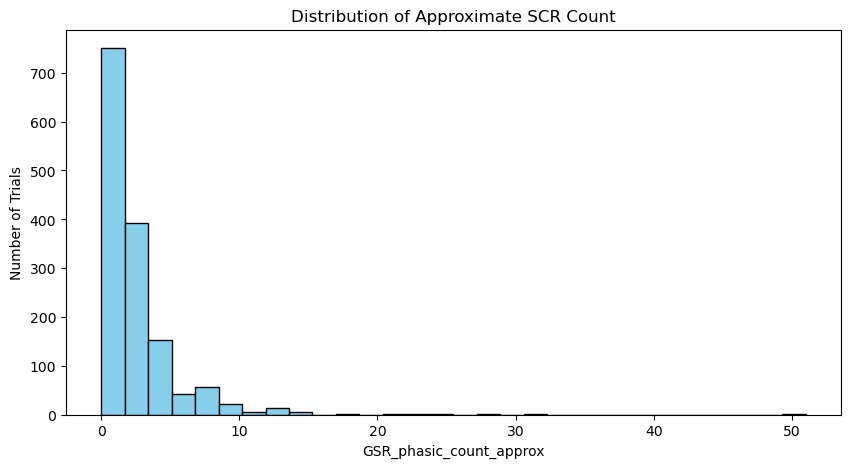

In [9]:
df['GSR_phasic_count_approx'] = (df['GSR_GSR Conductance CAL_std'] / 0.05).round()

# Basic statistics
print("Min:", df['GSR_phasic_count_approx'].min())
print("Max:", df['GSR_phasic_count_approx'].max())
print("Mean:", df['GSR_phasic_count_approx'].mean())
print("Median:", df['GSR_phasic_count_approx'].median())
print("Standard deviation:", df['GSR_phasic_count_approx'].std())

# Histogram
plt.figure(figsize=(10,5))
plt.hist(df['GSR_phasic_count_approx'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Approximate SCR Count')
plt.xlabel('GSR_phasic_count_approx')
plt.ylabel('Number of Trials')
plt.show()

In [10]:
df['GSR_phasic_count_scaled'] = (df['GSR_GSR Conductance CAL_std'] / 0.1).round()

In [11]:
# Approximate phasic rise/recovery time
df['GSR_rise_recovery_approx'] = df['GSR_GSR Conductance CAL_max'] - df['GSR_GSR Conductance CAL_min']


In [12]:
df.to_csv('cleaned_file.csv', index=False)
print("EEG + GSR feature engineering complete.")


EEG + GSR feature engineering complete.


In [23]:
# Identify numeric columns (EEG + GSR)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# 1. Replace inf/-inf with NaN
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

# 2. Interpolate missing values for numeric columns
df[numeric_cols] = df[numeric_cols].interpolate(method='linear', limit_direction='both')

# 3. Fill any remaining NaNs with column mean
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# 4. Normalize features
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Fill categorical/object columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check if any nulls remain
print(df.isnull().sum())

EEG_Delta_TP9_mean          0
EEG_Delta_TP9_std           0
EEG_Delta_TP9_min           0
EEG_Delta_TP9_max           0
EEG_Delta_TP9_median        0
                           ..
GSR_mean_conductance        0
GSR_peak_phasic             0
GSR_phasic_count_approx     0
GSR_phasic_count_scaled     0
GSR_rise_recovery_approx    0
Length: 131, dtype: int64


In [13]:
df.head()

,EEG_Delta_TP9_mean,EEG_Delta_TP9_std,EEG_Delta_TP9_min,EEG_Delta_TP9_max,EEG_Delta_TP9_median,EEG_Delta_AF7_mean,EEG_Delta_AF7_std,EEG_Delta_AF7_min,EEG_Delta_AF7_max,EEG_Delta_AF7_median,...,Theta_Alpha_ratio,Theta_Beta_ratio,Bandpower_slope,GSR_mean_conductance,GSR_peak_phasic,GSR_phasic_count_approx,GSR_phasic_count_scaled,GSR_rise_recovery_approx,GSR_mean_norm,EEG_ThetaBeta_ratio
0,0.249453,0.124189,-0.005580,0.441039,0.261609,-0.225233,0.173948,-0.564646,0.229248,-0.238338,...,0.426086,0.659631,-0.080358,18.194721,1.906239,28.0,14.0,4.191497,-0.068155,0.659631
1,1.033988,0.319011,0.397502,1.467339,1.136631,0.499656,0.400739,-0.429678,1.192548,0.520819,...,0.698964,1.278932,-0.164822,18.067476,0.757812,8.0,4.0,1.457912,-0.195400,1.278932
2,0.827583,0.188228,0.239536,1.063340,0.883827,0.614266,0.465170,-0.316656,1.192548,0.722867,...,0.764541,1.417727,-0.204494,17.455089,0.495452,5.0,2.0,0.874747,-0.807787,1.417727
3,0.960843,0.276460,0.327823,1.408459,0.976382,0.365654,0.443385,-0.484325,0.989337,0.396421,...,0.727336,1.744676,-0.219435,17.686396,1.612713,13.0,7.0,2.369107,-0.576479,1.744676
4,0.882369,0.232593,0.488667,1.464429,0.844921,0.468913,0.353725,-0.351208,1.023294,0.587266,...,0.703763,1.456875,-0.204928,16.484022,0.555323,6.0,3.0,1.020538,-1.778854,1.456875


In [14]:
print(df['Difficulty'].value_counts())


Difficulty
Easy         579
Difficult    452
Medium       417
Name: count, dtype: int64


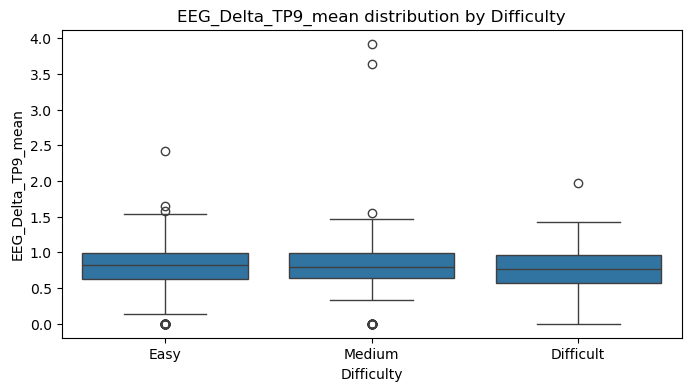

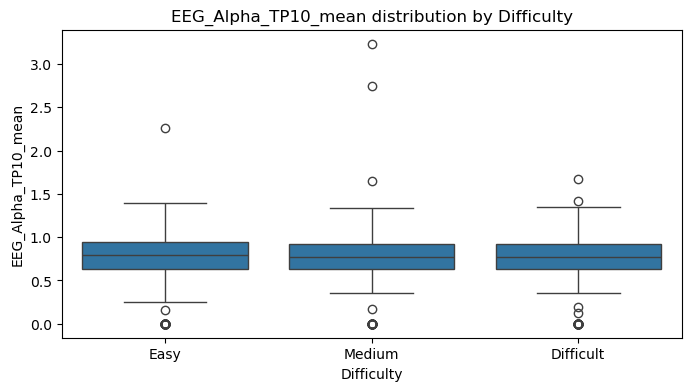

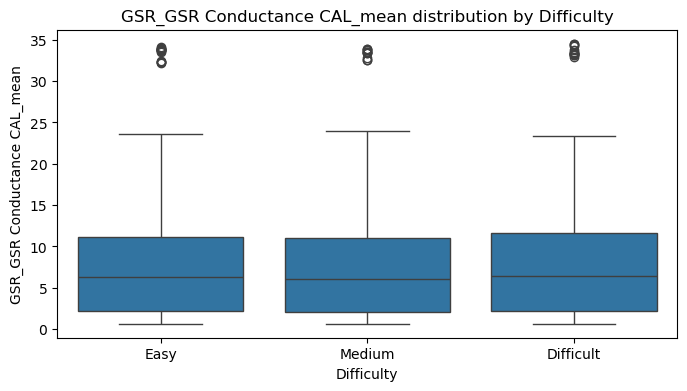

In [15]:
features_to_plot = ['EEG_Delta_TP9_mean', 'EEG_Alpha_TP10_mean', 'GSR_GSR Conductance CAL_mean']  # example

for feature in features_to_plot:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='Difficulty', y=feature, data=df)
    plt.title(f'{feature} distribution by Difficulty')
    plt.show()


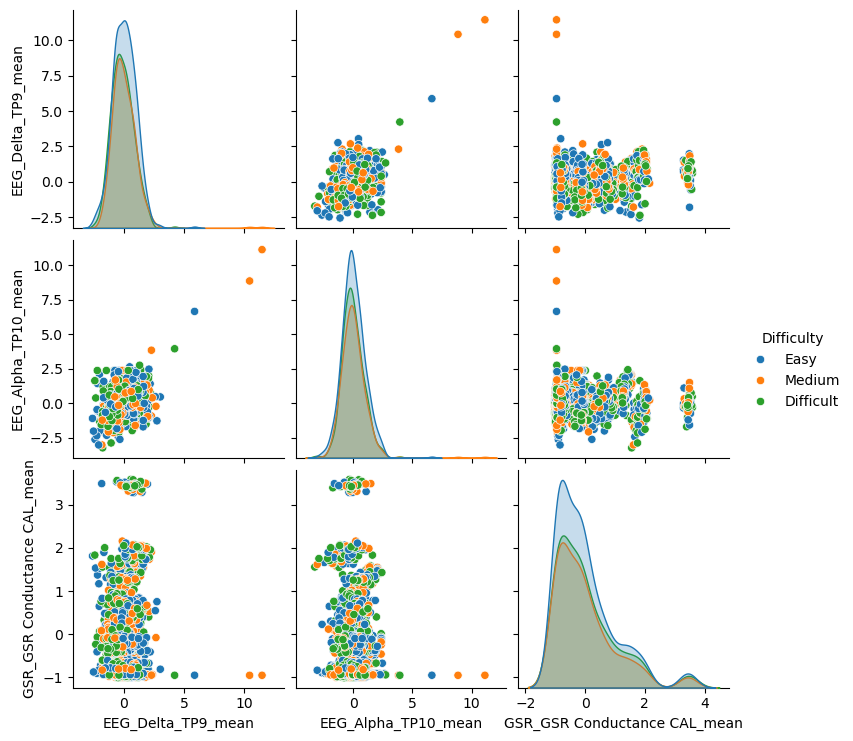

In [28]:
subset_features = ['EEG_Delta_TP9_mean', 'EEG_Alpha_TP10_mean', 'GSR_GSR Conductance CAL_mean', 'Difficulty']
sns.pairplot(df[subset_features], hue='Difficulty', diag_kind='kde')
plt.show()


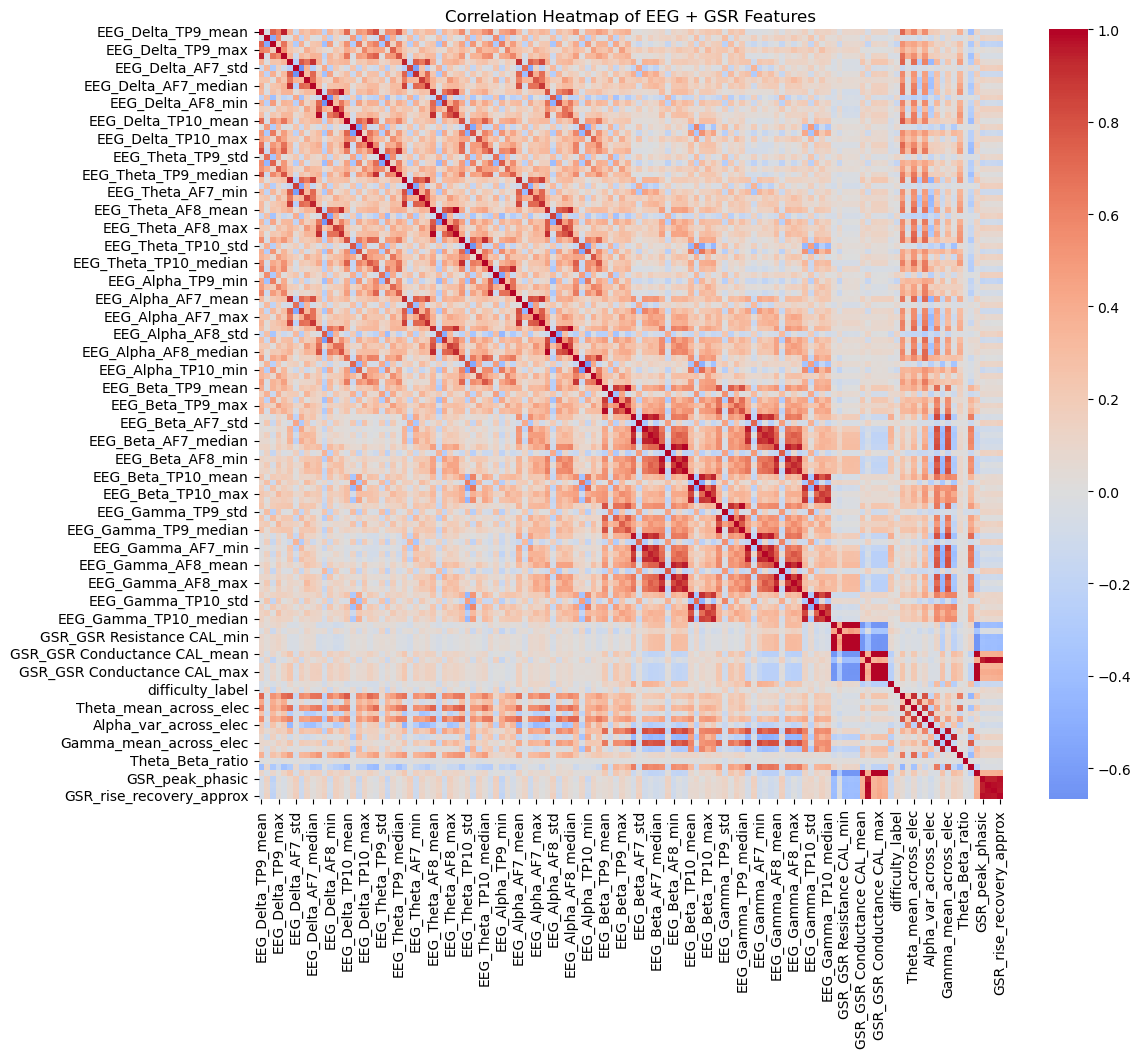

In [29]:
plt.figure(figsize=(12,10))
corr = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of EEG + GSR Features')
plt.show()


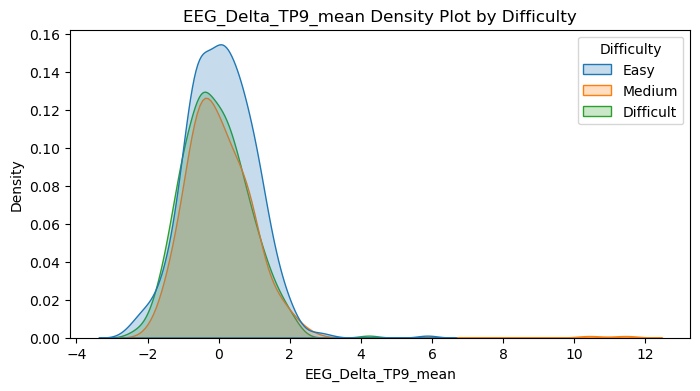

In [30]:
feature = 'EEG_Delta_TP9_mean'
plt.figure(figsize=(8,4))
sns.kdeplot(data=df, x=feature, hue='Difficulty', fill=True)
plt.title(f'{feature} Density Plot by Difficulty')
plt.show()


Class distribution:
Difficulty
Easy         579
Difficult    452
Medium       417
Name: count, dtype: int64


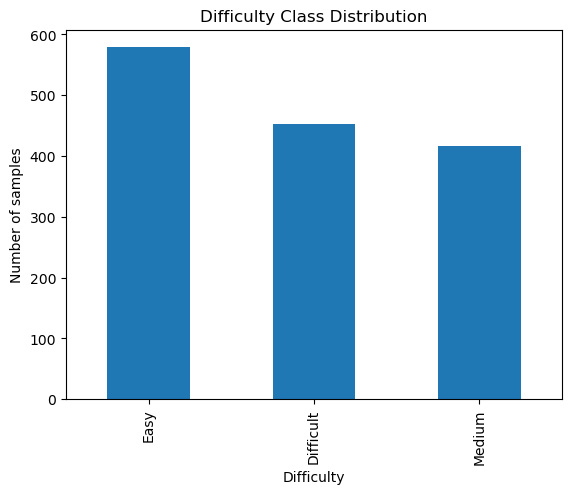

In [31]:
# Count of each class
target_counts = df['Difficulty'].value_counts()
print("Class distribution:")
print(target_counts)

# Optional: visualize
import matplotlib.pyplot as plt
target_counts.plot(kind='bar', title='Difficulty Class Distribution')
plt.ylabel('Number of samples')
plt.show()


In [32]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Compute skewness
skewness = df[numeric_cols].skew()
print("Skewness of numeric features:")
print(skewness)


Skewness of numeric features:
EEG_Delta_TP9_mean          2.085629
EEG_Delta_TP9_std           0.490356
EEG_Delta_TP9_min           1.284332
EEG_Delta_TP9_max           1.308937
EEG_Delta_TP9_median        1.820603
                              ...   
GSR_mean_conductance        1.495466
GSR_peak_phasic             4.285824
GSR_phasic_count_approx     4.931496
GSR_phasic_count_scaled     4.567123
GSR_rise_recovery_approx    3.786235
Length: 130, dtype: float64


In [33]:
gsr_cols = ['GSR_peak_phasic', 'GSR_phasic_count_approx', 'GSR_phasic_count_scaled', 'GSR_rise_recovery_approx']
df[gsr_cols] = df[gsr_cols].apply(lambda x: np.log1p(x))  # log transform

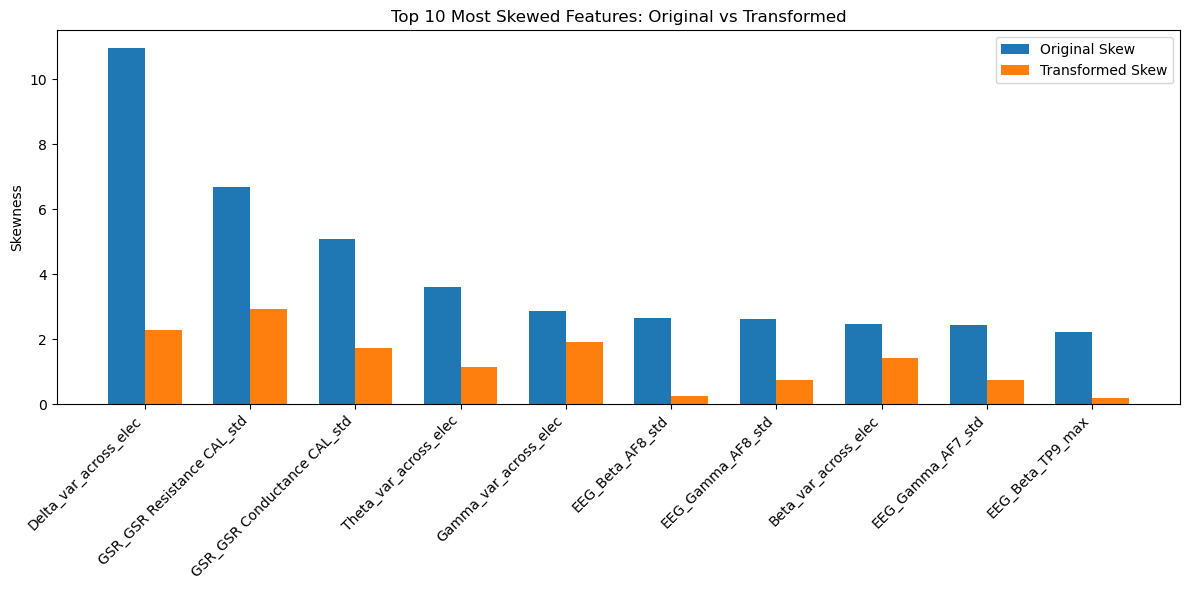

In [34]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Compute original skewness
original_skew = df[numeric_cols].skew()

# Apply log1p transform to positive numeric columns only
df_transformed = df[numeric_cols].copy()
for col in numeric_cols:
    if (df_transformed[col] >= 0).all():  # only positive values
        df_transformed[col] = np.log1p(df_transformed[col])
    else:
        min_val = df_transformed[col].min()
        df_transformed[col] = np.log1p(df_transformed[col] - min_val + 1)

# Compute skewness after transformation
transformed_skew = df_transformed.skew()

# Combine into a single table
skew_table = pd.DataFrame({
    'Original_Skew': original_skew,
    'Transformed_Skew': transformed_skew
}).sort_values(by='Original_Skew', ascending=False)

# Take top 10 most skewed features
top_skewed = skew_table.head(10)

# Plot
plt.figure(figsize=(12,6))
bar_width = 0.35
indices = np.arange(len(top_skewed))

plt.bar(indices, top_skewed['Original_Skew'], bar_width, label='Original Skew')
plt.bar(indices + bar_width, top_skewed['Transformed_Skew'], bar_width, label='Transformed Skew')

plt.xticks(indices + bar_width/2, top_skewed.index, rotation=45, ha='right')
plt.ylabel('Skewness')
plt.title('Top 10 Most Skewed Features: Original vs Transformed')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df["GSR_mean_norm"] = df.groupby("Participant")["GSR_mean_conductance"].transform(lambda x: x - x.mean())
df.to_csv("../data/all_participants_features.csv", index=False)


In [ ]:
df["EEG_ThetaBeta_ratio"] = df["Theta_Beta_ratio"].clip(-50, 50)
df.to_csv("../data/all_participants_features.csv", index=False)